Accuracy: 0.93


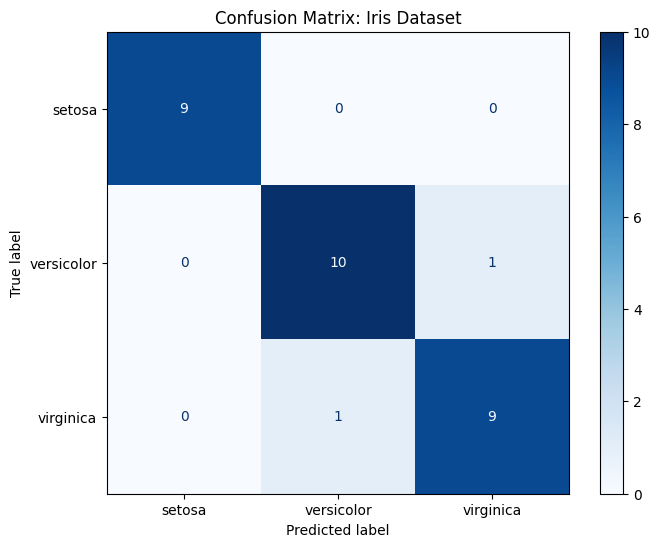

In [23]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Dataset setup
data = load_iris()
X = data.data
y = data.target

# 2. Split (using your random_state 41)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

# 3. Model initialization and training
# max_iter increased to ensure convergence on this dataset
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# 4. Predictions
predictions = model.predict(X_test)

# 5. Accuracy
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2f}')

# 6. CONFUSION MATRIX
cm = confusion_matrix(y_test, predictions)

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues', ax=ax)

plt.title('Confusion Matrix: Iris Dataset')
plt.show()

0.5558915986952425


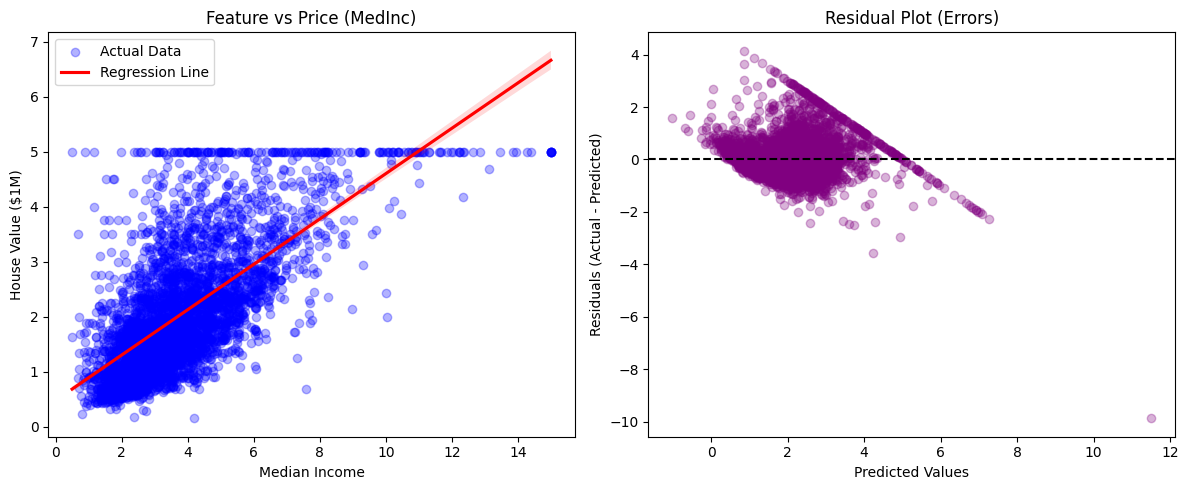

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Load Data
housing = fetch_california_housing()


## Applicare rimozione outlier con z score = 3


X = housing.data
y = housing.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Predictions and Residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred

mse = mean_squared_error(y_test, y_pred)

print(mse)

# 4. PLOTTING
plt.figure(figsize=(12, 5))

# --- Plot 1: Regression Line (using 'Median Income' which is index 0) ---
plt.subplot(1, 2, 1)
# Plotting only the first feature (Median Income) vs Target
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, label='Actual Data')
# Fit a simple line just for this plot to visualize the trend
sns.regplot(x=X_test[:, 0], y=y_test, scatter=False, color='red', label='Regression Line')
plt.title('Feature vs Price (MedInc)')
plt.xlabel('Median Income')
plt.ylabel('House Value ($1M)')
plt.legend()

# --- Plot 2: Residual Plot ---
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, color='purple', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--') # Zero error line
plt.title('Residual Plot (Errors)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

Rows removed: 482
Mean Squared Error: 0.4534


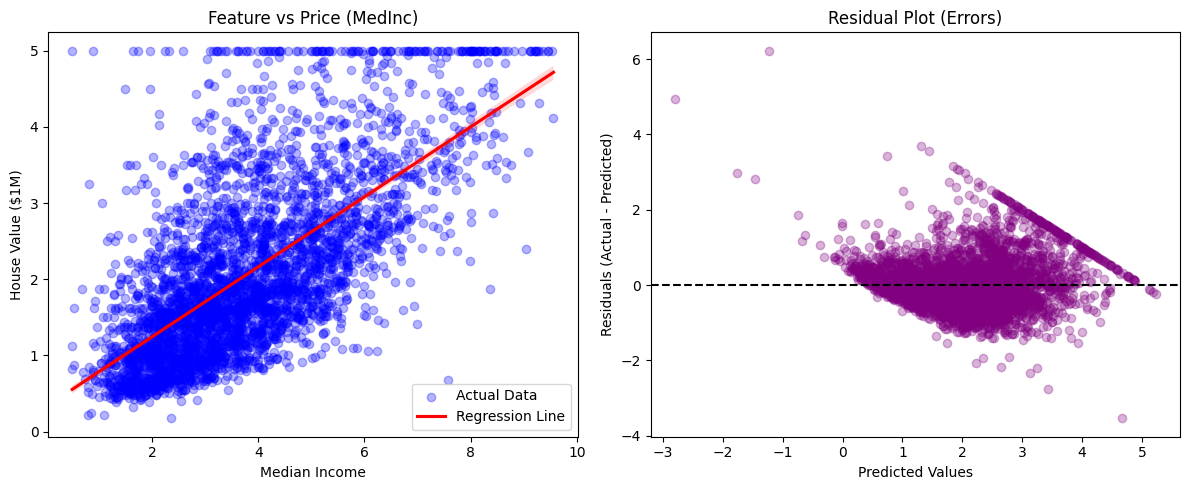

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
from scipy import stats
import pandas as pd

# 1. Load Data
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target to the dataframe so it stays synchronized during filtering
df_housing['MedHouseVal'] = housing.target

## Outlier removal function (stays the same)
def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    z_scores = np.abs(stats.zscore(df_clean[columns]))
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# 2. Apply filtering
df_zscore = remove_outliers_zscore(df_housing, ['MedInc', 'AveRooms', 'AveOccup'])
print(f"Rows removed: {len(df_housing) - len(df_zscore)}")

# 3. Redefine X and y from the cleaned DataFrame
# X is everything except the target; y is just the target
X = df_zscore.drop(columns=['MedHouseVal']).values 
y = df_zscore['MedHouseVal'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)
residuals = y_test - y_pred

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

# 4. PLOTTING
plt.figure(figsize=(12, 5))

# --- Plot 1: Regression Line (using 'Median Income' which is index 0) ---
plt.subplot(1, 2, 1)
# Plotting only the first feature (Median Income) vs Target
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, label='Actual Data')
# Fit a simple line just for this plot to visualize the trend
sns.regplot(x=X_test[:, 0], y=y_test, scatter=False, color='red', label='Regression Line')
plt.title('Feature vs Price (MedInc)')
plt.xlabel('Median Income')
plt.ylabel('House Value ($1M)')
plt.legend()

# --- Plot 2: Residual Plot ---
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, color='purple', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--') # Zero error line
plt.title('Residual Plot (Errors)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns

# Load the built-in titanic dataset
df = sns.load_dataset('titanic')

# Display the first 5 rows
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


# Da fare - Fatto in Esempio_con_RegressioneLineare.ipynb

- ripulire il dataset
- convertire categorie in numeri
- rimuovere outlier con z-score 3
- feature engineering
- normalizzare
- applicare logistic regression

1- rimuovere la colonna class 
